In [29]:
import pandas as pd
import numpy as np
import os

import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import itertools

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import random

In [2]:
#!pip install matplotlib scikit-learn pandas seaborn optuna

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DATASET PREPARATION

In [4]:
def read_img_labels(xml_path):
    XMLtree = ET.parse(xml_path)
    XMLroot = XMLtree.getroot()
    img_labels = []

    for obj in XMLroot.findall('object'):
        label_name = obj.find('name').text
        bounding_box = obj.find('bndbox')
        
        x_min = int(bounding_box.find('xmin').text)
        y_min = int(bounding_box.find('ymin').text)
        x_max = int(bounding_box.find('xmax').text)
        y_max = int(bounding_box.find('ymax').text)

        img_labels.append((label_name, (x_min, y_min, x_max, y_max)))

    return img_labels

In [5]:
def read_files(files):
    data = []
    dimensions = []

    for file_name in files:
        img_path = os.path.join(data_directory, 'Images', file_name + '.jpg')
        xml_path = os.path.join(data_directory, 'Labels', 'Horizontal Bounding Boxes', file_name + '.xml')

        image = Image.open(img_path)
        image_array = np.array(image)
        if (image_array.shape[2]) != 3:
            continue

        img_labels = read_img_labels(xml_path)

        for label in img_labels:
            width = abs(label[1][0] - label[1][2])
            height = abs(label[1][1] - label[1][3])
            dimensions.append(width)
            dimensions.append(height)

        data.append((image, img_labels))

    return data, dimensions

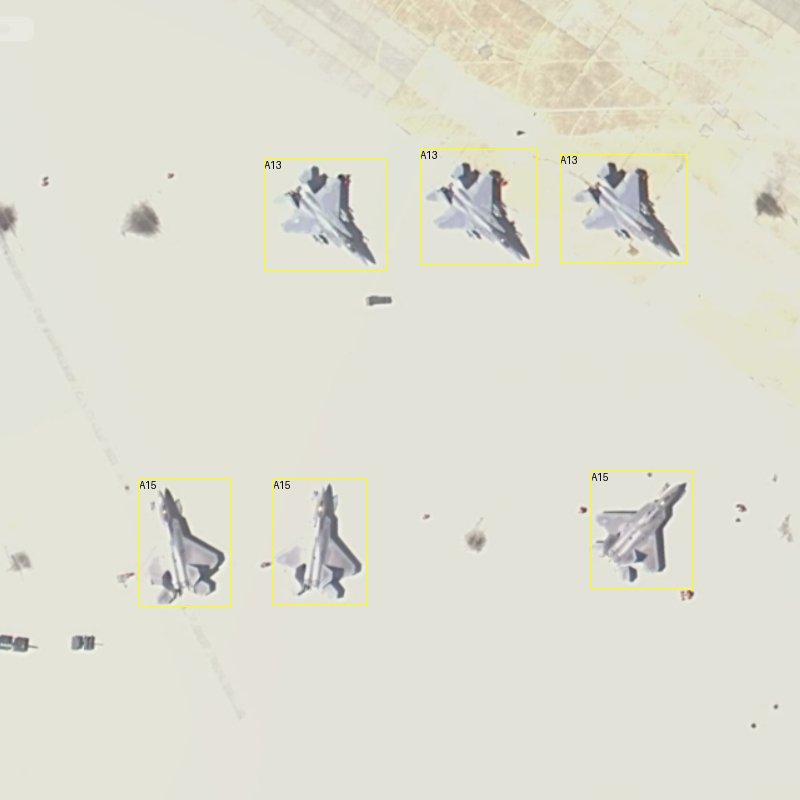

In [6]:
data_directory = './datasets'

with open(os.path.join(data_directory, 'ImageSets/Main/train.txt'), 'r') as f:
    train_fnames = f.read().splitlines()
    
train_data, train_obj_dimensions = read_files(train_fnames)

image = train_data[3][0]
img_to_draw = ImageDraw.Draw(image)
img_objects = train_data[3][1]

for obj in img_objects:
    img_to_draw.text((obj[1][0], obj[1][1]), obj[0], fill='black')
    img_to_draw.rectangle(obj[1], outline='yellow')
image

# PREPROCESSING

In [7]:
def square_img(image):
    image_original_size = image.size
    image_desired_size = (64, 64)

    image_max_dimension = max(image_original_size)

    squares = Image.new("RGB", (image_max_dimension, image_max_dimension))

    x = (image_max_dimension - image_original_size[0]) // 2
    y = (image_max_dimension - image_original_size[1]) // 2
    squares.paste(image, (x, y))

    new_image = squares.resize(image_desired_size)

    return new_image

In [8]:
def object_from_image(image, image_labels):
    objects = []
    labels = []

    for label, bounding_box in image_labels:
        labels.append(label)
        obj_region = image.crop(bounding_box)
        objects.append(obj_region)

    labels = np.array(labels)

    return objects, labels

In [9]:
def data_prep(data):
    X_temporary = []
    y_temporary = []

    for image, image_labels in data:
        objects, labels = object_from_image(image, image_labels)

        squares = []
        for obj in objects:
            square_image = square_img(obj)
            squares.append(square_image)

        X_temporary.append(squares)
        y_temporary.append(labels)

    original_labels = list(itertools.chain(*y_temporary))
    original_labels_np = np.array(original_labels).reshape(-1, 1)

    OHEncoder = OneHotEncoder()
    y = OHEncoder.fit_transform(original_labels_np).toarray()

    n_channels = 4
    X_list = []

    for image in X_temporary:
        for obj in image:
            X_list.append(np.array(obj)/255.0)

    X = np.array(X_list)

    return X, y, original_labels_np

Liczba klas: 20


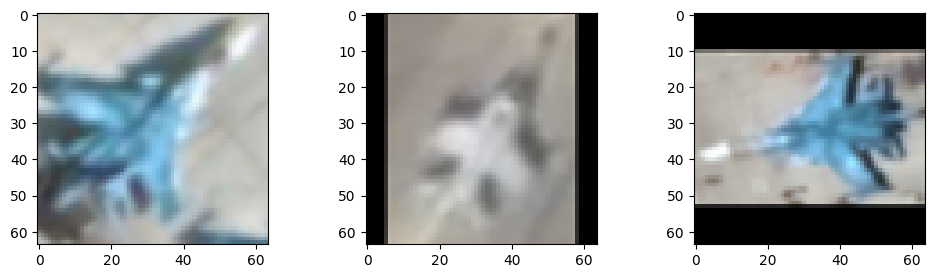

In [10]:
X, y, original_labels = data_prep(train_data)
n_labels = y.shape[1]
print("Liczba klas:", n_labels)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3))
ax0.imshow(X[3], cmap='gray')
ax1.imshow(X[43], cmap='gray')
ax2.imshow(X[80], cmap='gray')

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.7, random_state=10)

print("Dane treningowe:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("Dane testowe:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Dane treningowe:
X_train: (5468, 64, 64, 3)
y_train: (5468, 20)
Dane testowe:
X_test: (2344, 64, 64, 3)
y_test: (2344, 20)


# MODEL

In [12]:
class CNN(nn.Module):
    def __init__(self, conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential()
        
        in_channels = 3
        for i in range(conv_layers):
            out_channels = filters[i]
            kernel_size = kernel_sizes[i]
            stride = strides[i]
            self.conv_layers.add_module(f'conv{i+1}', nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=1))
            self.conv_layers.add_module(f'relu{i+1}', nn.ReLU())
            self.conv_layers.add_module(f'pool{i+1}', nn.AvgPool2d(kernel_size=2, stride=2))
            in_channels = out_channels
        
        self.flatten = nn.Flatten()
        
        self._to_linear = self.calculate_linear_input(conv_layers, filters, kernel_sizes, strides)
        
        self.fc1 = nn.Linear(self._to_linear, dense_units)
        self.fc2 = nn.Linear(dense_units, 20)
        
        self.dropout = nn.Dropout(dropout_rate)
    
    def calculate_linear_input(self, conv_layers, filters, kernel_sizes, strides):
        size = 64 
        for i in range(conv_layers):
            size = (size - kernel_sizes[i] + 2 * 1) // strides[i] + 1
            size = size // 2
        return filters[-1] * size * size
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [13]:
def create_model(conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate):
    model = CNN(conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate)
    return model

In [14]:
# conv_layers_best = best_trial_params['conv_layers']
# filters_best = [best_trial_params[f'filters_{i}'] for i in range(conv_layers_best)]
# kernel_sizes_best = [best_trial_params[f'kernel_size_{i}'] for i in range(conv_layers_best)]
# strides_best = [best_trial_params[f'stride_{i}'] for i in range(conv_layers_best)]
# dense_units_best = best_trial_params['units']
# dropout_rate_best = best_trial_params['dropout']

# best_model_manual_params = create_model(conv_layers_best,
#                                         filters_best,
#                                         kernel_sizes_best,
#                                         strides_best,
#                                         dense_units_best,
#                                         dropout_rate_best).to(device)
# print(best_model_manual_params)


# Teraz możesz ręcznie uruchomić model z własnymi parametrami:
manual_conv_layers = 3
manual_filters = [96, 64, 96]
manual_kernel_sizes = [2, 3, 2]
manual_strides = [1, 1, 1]
manual_dense_units = 64
manual_dropout_rate = 0.5

manual_model = create_model(manual_conv_layers,
                            manual_filters,
                            manual_kernel_sizes,
                            manual_strides,
                            manual_dense_units,
                            manual_dropout_rate).to(device)

# print(manual_model)

Epoch 0, Training Loss: 0.1563
Epoch 0, Validation Loss: 0.4106, Accuracy: 0.8955
Epoch 5, Training Loss: 0.1000
Epoch 5, Validation Loss: 0.3594, Accuracy: 0.9202
Epoch 10, Training Loss: 0.1006
Epoch 10, Validation Loss: 0.4284, Accuracy: 0.9036
Epoch 15, Training Loss: 0.0879
Epoch 15, Validation Loss: 0.4672, Accuracy: 0.9040
Epoch 20, Training Loss: 0.0612
Epoch 20, Validation Loss: 0.4955, Accuracy: 0.9006
Epoch 25, Training Loss: 0.0467
Epoch 25, Validation Loss: 0.4417, Accuracy: 0.9108
Epoch 30, Training Loss: 0.0553
Epoch 30, Validation Loss: 0.5877, Accuracy: 0.9010
Epoch 35, Training Loss: 0.0422
Epoch 35, Validation Loss: 0.5092, Accuracy: 0.9108
Epoch 40, Training Loss: 0.0519
Epoch 40, Validation Loss: 0.4693, Accuracy: 0.9151
Epoch 45, Training Loss: 0.0276
Epoch 45, Validation Loss: 0.5001, Accuracy: 0.9151
Epoch 50, Training Loss: 0.0422
Epoch 50, Validation Loss: 0.5524, Accuracy: 0.8955
Epoch 55, Training Loss: 0.0434
Epoch 55, Validation Loss: 0.5334, Accuracy: 0.9

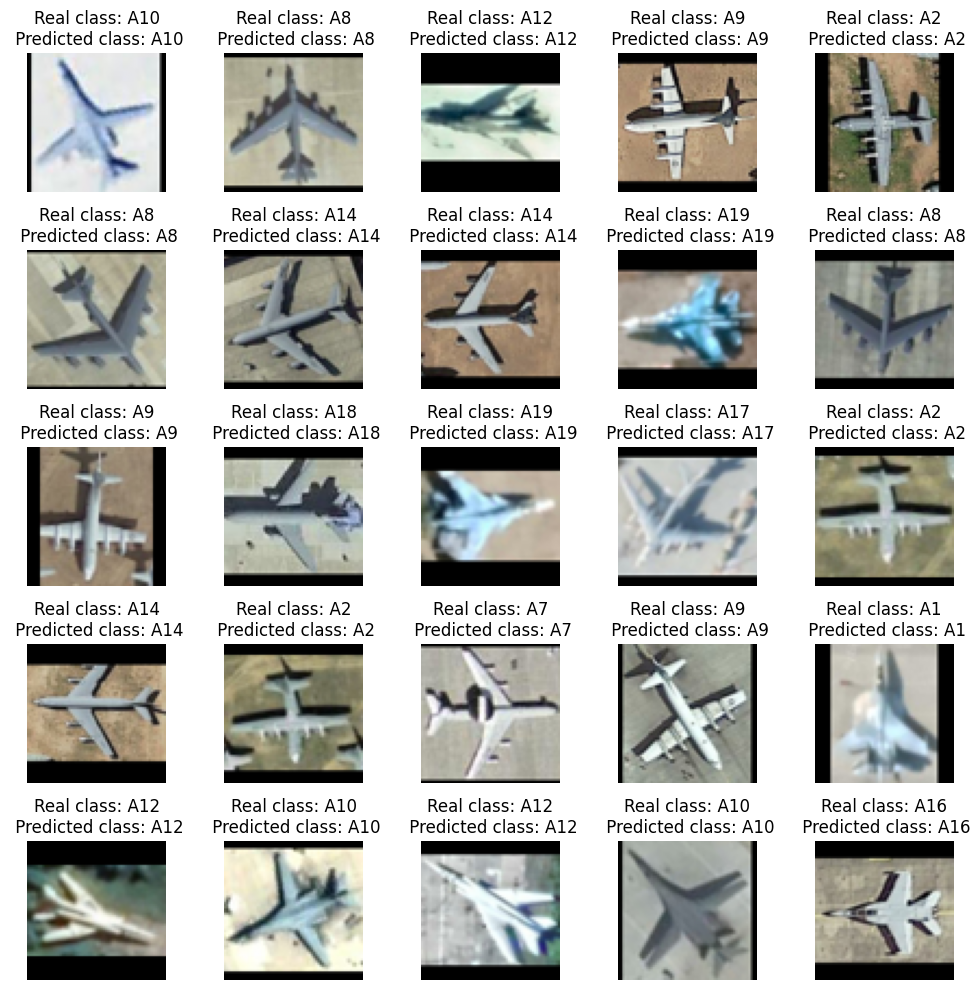

In [36]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train.argmax(axis=1), dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_test_tensor = torch.tensor(y_test.argmax(axis=1), dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Optymalizator i funkcja straty
optimizer = optim.Adam(manual_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(100):
    manual_model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = manual_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Training Loss: {avg_train_loss:.4f}')
    
    manual_model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = manual_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    avg_val_loss = val_loss / len(test_loader)
    accuracy = correct / total
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Validation Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.4f}')

manual_model.eval()
predictions = []
with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch[0].to(device)
        outputs = manual_model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        predictions.extend(predicted.cpu().numpy())

encoder = OneHotEncoder()
encoder.fit(original_labels.reshape(-1, 1))

y_test_np = y_test_tensor.cpu().numpy()
predictions_np = np.array(predictions)
y_orig_true = encoder.categories_[0][y_test_np.astype(int)]
y_orig_pred = encoder.categories_[0][predictions_np.astype(int)]

fig, axs = plt.subplots(5, 5, figsize=(10, 10))
axs = axs.ravel()

random_numbers = [random.randint(0, X_test.shape[0]) for _ in range(25)]

for i, rand in enumerate(random_numbers):
    axs[i].imshow(X_test[rand], cmap='gray')
    axs[i].axis('off')
    axs[i].set_title(f"Real class: {y_orig_true[rand]}\n Predicted class: {y_orig_pred[rand]}")

plt.tight_layout()
plt.show()